In [1]:
# Biblioteca para operações numéricas
import numpy as np

# Para Visualização
import matplotlib.pyplot as plt

# Para Redes Neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Camadas de Data Augmentation (ativas apenas durante o treino)
from tensorflow.keras.layers import RandomFlip, RandomTranslation

# Callbacks para controlar o treino
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

# Carregar a base de dados CIFAR-10

In [2]:
# Carregar a base CIFAR
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar valores para intervalo [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo", "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_test: {y_test.shape}")

Formato de X_train: (50000, 32, 32, 3)
Formato de y_train: (50000,)
Formato de X_test: (10000, 32, 32, 3)
Formato de y_test: (10000,)


# Plotar Algumas Imagens

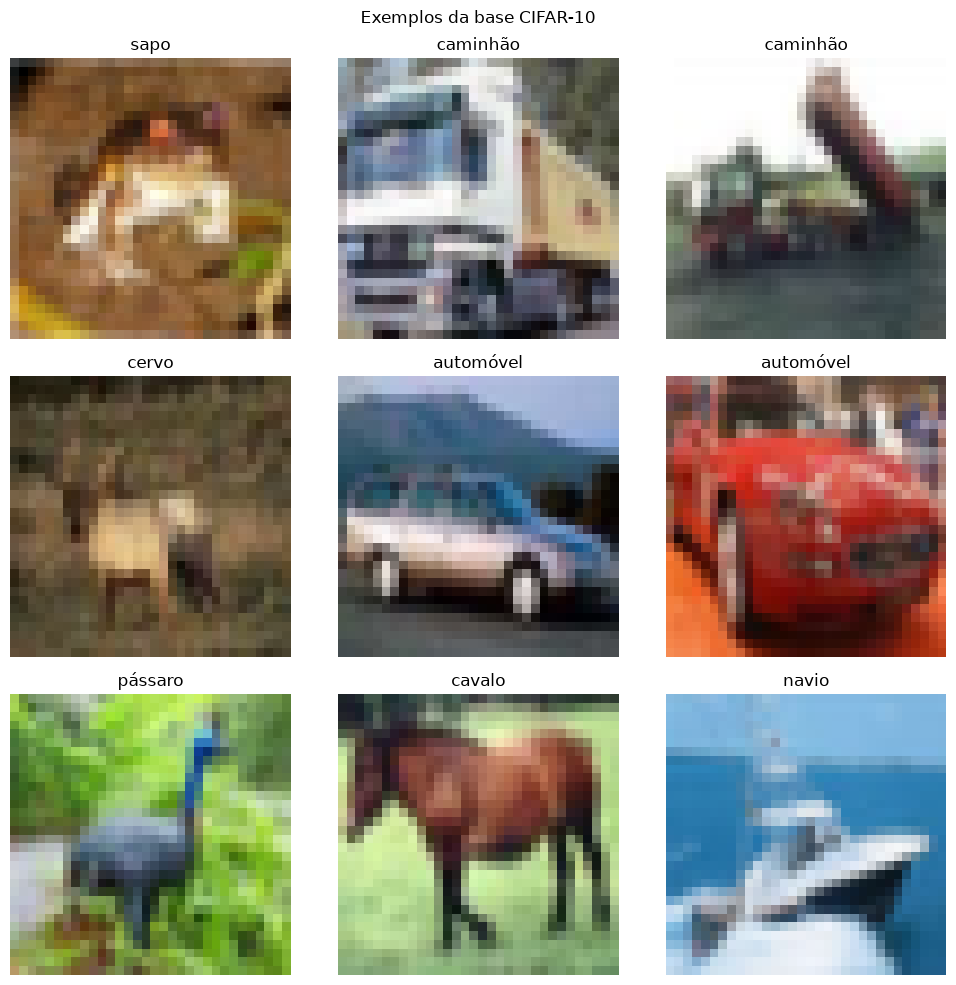

In [3]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Exemplos da base CIFAR-10")
plt.tight_layout()
plt.show()

# Criação do Modelo CNN

In [4]:
model = keras.Sequential()

# Definir a Camada de Entrada
model.add(Input(shape=(32,32,3)))

# Data Augmentation: espelhamento horizontal e deslocamento de até 10%
model.add(RandomFlip("horizontal"))
model.add(RandomTranslation(height_factor=0.1, width_factor=0.1))

# Bloco 1 (padding='same' mantém o tamanho da imagem após a convolução)
model.add(Conv2D(filters = 32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Bloco 2
model.add(Conv2D(filters = 64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Bloco 3
model.add(Conv2D(filters = 128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

# Transicao CNN -> Dense (Totalmente Conectada)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compilacao do Modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

# Treinar a Rede

In [5]:
# Para o treino quando a val_loss para de melhorar e restaura os melhores pesos
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Reduz a taxa de aprendizado pela metade quando a val_loss estagna
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.2876 - loss: 1.9535 - val_accuracy: 0.4312 - val_loss: 1.5567 - learning_rate: 0.0010
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4243 - loss: 1.5753 - val_accuracy: 0.5142 - val_loss: 1.3614 - learning_rate: 0.0010
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.4992 - loss: 1.3936 - val_accuracy: 0.5818 - val_loss: 1.1546 - learning_rate: 0.0010
Epoch 4/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.5579 - loss: 1.2507 - val_accuracy: 0.6360 - val_loss: 1.0060 - learning_rate: 0.0010
Epoch 5/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.6000 - loss: 1.1362 - val_accuracy: 0.6585 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 6/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6317 - loss: 1.0572 - val_accuracy: 0.6231 - val_loss: 1.0822 - learning_rate: 0.0010
Epoch 7/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6587 - l

# Plot da Acuraria e do Loss

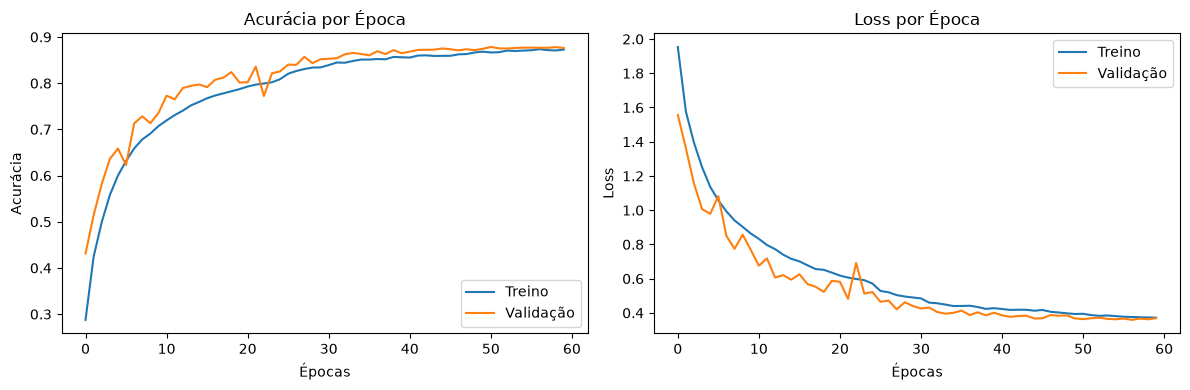

In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por Época')
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Realizando Predições 

In [7]:
test_loss, test_acc = model.evaluate(X_test , y_test)

print(f"Acurácia no conjunto de teste: {test_acc}")
print(f"Loss no conjunto de teste: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8729 - loss: 0.3780
Acurácia no conjunto de teste: 0.8729000091552734
Loss no conjunto de teste: 0.37804803252220154


# Previsões em Imagens do Teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


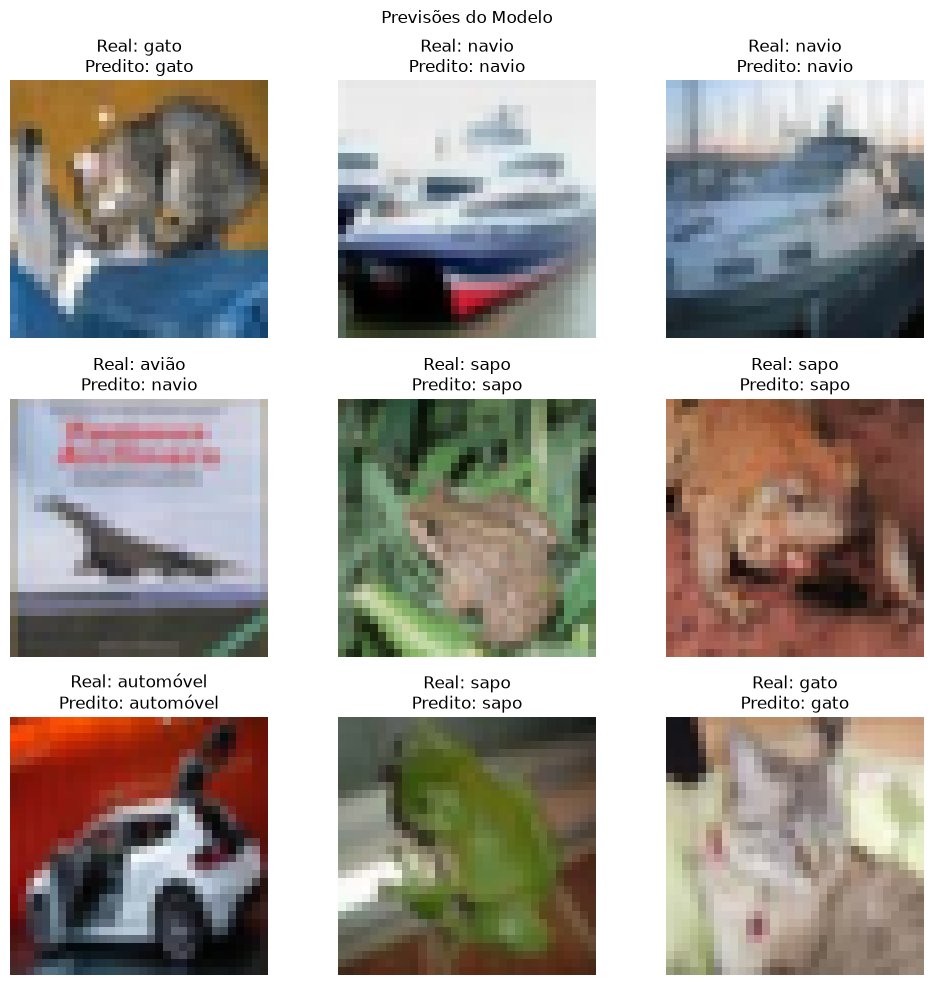

In [8]:
pred_probs = model.predict(X_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real}\nPredito: {pred}")
    plt.axis('off')
plt.suptitle("Previsões do Modelo")
plt.tight_layout()
plt.show()